# comparison_multi

GLAD / EfficientAD / PUAD の結果 JSON を Drive から自動で読み込み、
5カテゴリの比較表と平均表を作成する notebook です。


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os, json, pandas as pd, numpy as np

BASE_DIR = "/content/drive/MyDrive/industrial-anomaly-detection-app"
COMPARISON_ROOT = f"{BASE_DIR}/comparison"
TABLE_ROOT = f"{COMPARISON_ROOT}/tables"
FIG_ROOT = f"{COMPARISON_ROOT}/figures"
os.makedirs(TABLE_ROOT, exist_ok=True)
os.makedirs(FIG_ROOT, exist_ok=True)

CATEGORIES = ["bottle", "cable", "capsule", "pill", "grid"]


In [3]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

rows = []

for category in CATEGORIES:
    glad_json = f"{COMPARISON_ROOT}/GLAD/{category}/metrics.json"
    eff_json = f"{COMPARISON_ROOT}/EfficientAD/{category}/pixel_metrics.json"
    puad_json = f"{COMPARISON_ROOT}/PUAD/{category}/metrics.json"

    if os.path.exists(glad_json):
        m = load_json(glad_json)
        rows.append({
            "Method": "GLAD",
            "Dataset": "MVTec-AD",
            "Category": category,
            "Image_AUROC": m.get("I_AUROC"),
            "Pixel_AUROC": m.get("P_AUROC"),
            "Pixel_AP": m.get("P_AP"),
            "PRO_or_AUPRO": m.get("PRO"),
            "Notes": f"checkpoint_step={m.get('checkpoint_step')}",
        })

    if os.path.exists(eff_json):
        m = load_json(eff_json)
        rows.append({
            "Method": "EfficientAD",
            "Dataset": "MVTec-AD",
            "Category": category,
            "Image_AUROC": m.get("Image_AUROC", np.nan) * 100,
            "Pixel_AUROC": m.get("Pixel_AUROC", np.nan) * 100,
            "Pixel_AP": m.get("Pixel_AP", np.nan) * 100,
            "PRO_or_AUPRO": m.get("AUPRO", np.nan) * 100,
            "Notes": "efficient_ad_pixel_eval",
        })

    if os.path.exists(puad_json):
        m = load_json(puad_json)
        rows.append({
            "Method": "PUAD",
            "Dataset": "MVTec-AD",
            "Category": category,
            "Image_AUROC": m.get("Image_AUROC"),
            "Pixel_AUROC": np.nan,
            "Pixel_AP": np.nan,
            "PRO_or_AUPRO": np.nan,
            "Notes": f"feature_extractor={m.get('feature_extractor')}",
        })

df = pd.DataFrame(rows)
df


,Method,Dataset,Category,Image_AUROC,Pixel_AUROC,Pixel_AP,PRO_or_AUPRO,Notes
0,GLAD,MVTec-AD,bottle,100.000000,98.710000,85.500000,96.150000,checkpoint_step=2500
1,EfficientAD,MVTec-AD,bottle,100.000000,97.162481,55.720265,88.989943,efficient_ad_pixel_eval
2,PUAD,MVTec-AD,bottle,99.920635,NaN,NaN,NaN,feature_extractor=student
3,GLAD,MVTec-AD,cable,99.190000,98.120000,68.610000,94.010000,checkpoint_step=1500
4,EfficientAD,MVTec-AD,cable,97.245127,98.230947,66.039231,90.742948,efficient_ad_pixel_eval
5,PUAD,MVTec-AD,cable,97.769865,NaN,NaN,NaN,feature_extractor=student
6,GLAD,MVTec-AD,capsule,98.480000,98.540000,53.670000,94.240000,checkpoint_step=2000
7,EfficientAD,MVTec-AD,capsule,98.444356,98.604990,33.174296,91.913796,efficient_ad_pixel_eval
8,PUAD,MVTec-AD,capsule,98.045473,NaN,NaN,NaN,feature_extractor=student
9,GLAD,MVTec-AD,pill,98.690000,97.900000,75.990000,97.600000,checkpoint_step=1500


In [4]:
# 並び替え
method_order = {"GLAD": 0, "EfficientAD": 1, "PUAD": 2}
category_order = {c: i for i, c in enumerate(CATEGORIES)}

if not df.empty:
    df["method_order"] = df["Method"].map(method_order)
    df["category_order"] = df["Category"].map(category_order)
    df = df.sort_values(["category_order", "method_order"]).drop(columns=["method_order", "category_order"]).reset_index(drop=True)

df


,Method,Dataset,Category,Image_AUROC,Pixel_AUROC,Pixel_AP,PRO_or_AUPRO,Notes
0,GLAD,MVTec-AD,bottle,100.000000,98.710000,85.500000,96.150000,checkpoint_step=2500
1,EfficientAD,MVTec-AD,bottle,100.000000,97.162481,55.720265,88.989943,efficient_ad_pixel_eval
2,PUAD,MVTec-AD,bottle,99.920635,NaN,NaN,NaN,feature_extractor=student
3,GLAD,MVTec-AD,cable,99.190000,98.120000,68.610000,94.010000,checkpoint_step=1500
4,EfficientAD,MVTec-AD,cable,97.245127,98.230947,66.039231,90.742948,efficient_ad_pixel_eval
5,PUAD,MVTec-AD,cable,97.769865,NaN,NaN,NaN,feature_extractor=student
6,GLAD,MVTec-AD,capsule,98.480000,98.540000,53.670000,94.240000,checkpoint_step=2000
7,EfficientAD,MVTec-AD,capsule,98.444356,98.604990,33.174296,91.913796,efficient_ad_pixel_eval
8,PUAD,MVTec-AD,capsule,98.045473,NaN,NaN,NaN,feature_extractor=student
9,GLAD,MVTec-AD,pill,98.690000,97.900000,75.990000,97.600000,checkpoint_step=1500


In [5]:
# 保存
comparison_csv = f"{TABLE_ROOT}/multi_category_comparison_raw.csv"
df.to_csv(comparison_csv, index=False)
print("saved:", comparison_csv)


saved: /content/drive/MyDrive/industrial-anomaly-detection-app/comparison/tables/multi_category_comparison_raw.csv


In [6]:
# 表示用に丸める
display_df = df.copy()
for col in ["Image_AUROC", "Pixel_AUROC", "Pixel_AP", "PRO_or_AUPRO"]:
    display_df[col] = display_df[col].map(lambda x: None if pd.isna(x) else round(float(x), 3))
display_df


,Method,Dataset,Category,Image_AUROC,Pixel_AUROC,Pixel_AP,PRO_or_AUPRO,Notes
0,GLAD,MVTec-AD,bottle,100.000,98.710,85.500,96.150,checkpoint_step=2500
1,EfficientAD,MVTec-AD,bottle,100.000,97.162,55.720,88.990,efficient_ad_pixel_eval
2,PUAD,MVTec-AD,bottle,99.921,NaN,NaN,NaN,feature_extractor=student
3,GLAD,MVTec-AD,cable,99.190,98.120,68.610,94.010,checkpoint_step=1500
4,EfficientAD,MVTec-AD,cable,97.245,98.231,66.039,90.743,efficient_ad_pixel_eval
5,PUAD,MVTec-AD,cable,97.770,NaN,NaN,NaN,feature_extractor=student
6,GLAD,MVTec-AD,capsule,98.480,98.540,53.670,94.240,checkpoint_step=2000
7,EfficientAD,MVTec-AD,capsule,98.444,98.605,33.174,91.914,efficient_ad_pixel_eval
8,PUAD,MVTec-AD,capsule,98.045,NaN,NaN,NaN,feature_extractor=student
9,GLAD,MVTec-AD,pill,98.690,97.900,75.990,97.600,checkpoint_step=1500


In [7]:
# 方法ごとの平均
summary_df = (
    df.groupby("Method")[["Image_AUROC", "Pixel_AUROC", "Pixel_AP", "PRO_or_AUPRO"]]
      .mean(numeric_only=True)
      .reset_index()
)

for col in ["Image_AUROC", "Pixel_AUROC", "Pixel_AP", "PRO_or_AUPRO"]:
    summary_df[col] = summary_df[col].map(lambda x: None if pd.isna(x) else round(float(x), 3))

summary_df


,Method,Image_AUROC,Pixel_AUROC,Pixel_AP,PRO_or_AUPRO
0,EfficientAD,98.772,97.989,45.683,91.009
1,GLAD,99.272,98.568,67.688,96.066
2,PUAD,98.749,NaN,NaN,NaN


In [8]:
summary_csv = f"{TABLE_ROOT}/multi_category_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print("saved:", summary_csv)


saved: /content/drive/MyDrive/industrial-anomaly-detection-app/comparison/tables/multi_category_summary.csv


In [9]:
# カテゴリ x 手法 の Image_AUROC ピボット
image_pivot = df.pivot(index="Category", columns="Method", values="Image_AUROC")
image_pivot


Method,EfficientAD,GLAD,PUAD
Category,,,
bottle,100.000000,100.00,99.920635
cable,97.245127,99.19,97.769865
capsule,98.444356,98.48,98.045473
grid,100.000000,100.00,100.000000
pill,98.172395,98.69,98.008729


In [10]:
# GLAD vs EfficientAD の pixel 指標比較
pixel_compare_df = df[df["Method"].isin(["GLAD", "EfficientAD"])][["Method", "Category", "Pixel_AUROC", "Pixel_AP", "PRO_or_AUPRO"]].copy()
for col in ["Pixel_AUROC", "Pixel_AP", "PRO_or_AUPRO"]:
    pixel_compare_df[col] = pixel_compare_df[col].map(lambda x: None if pd.isna(x) else round(float(x), 3))
pixel_compare_df


,Method,Category,Pixel_AUROC,Pixel_AP,PRO_or_AUPRO
0,GLAD,bottle,98.710,85.500,96.150
1,EfficientAD,bottle,97.162,55.720,88.990
3,GLAD,cable,98.120,68.610,94.010
4,EfficientAD,cable,98.231,66.039,90.743
6,GLAD,capsule,98.540,53.670,94.240
7,EfficientAD,capsule,98.605,33.174,91.914
9,GLAD,pill,97.900,75.990,97.600
10,EfficientAD,pill,97.752,48.868,89.810
12,GLAD,grid,99.570,54.670,98.330
13,EfficientAD,grid,98.195,24.614,93.589


In [11]:
pixel_compare_csv = f"{TABLE_ROOT}/multi_category_pixel_compare.csv"
pixel_compare_df.to_csv(pixel_compare_csv, index=False)
print("saved:", pixel_compare_csv)


saved: /content/drive/MyDrive/industrial-anomaly-detection-app/comparison/tables/multi_category_pixel_compare.csv


In [12]:
# anomaly-wise AUROC の読込
anomaly_rows = []
for category in CATEGORIES:
    path = f"{COMPARISON_ROOT}/PUAD/{category}/anomaly_breakdown.json"
    if os.path.exists(path):
        m = load_json(path)
        for k, v in m.items():
            anomaly_rows.append({
                "Category": category,
                "Method": "PUAD",
                "AnomalyType": k,
                "AUROC": float(v) * 100 if v <= 1.0 else float(v),
            })

anomaly_df = pd.DataFrame(anomaly_rows)
if not anomaly_df.empty:
    anomaly_df["AUROC"] = anomaly_df["AUROC"].map(lambda x: round(float(x), 3))
anomaly_df


,Category,Method,AnomalyType,AUROC
0,bottle,PUAD,broken_large,100.000
1,bottle,PUAD,broken_small,100.000
2,bottle,PUAD,contamination,99.762
3,cable,PUAD,bent_wire,99.867
4,cable,PUAD,cable_swap,99.856
5,cable,PUAD,combined,99.687
6,cable,PUAD,cut_inner_insulation,97.783
7,cable,PUAD,cut_outer_insulation,97.931
8,cable,PUAD,missing_cable,100.000
9,cable,PUAD,missing_wire,97.414


In [13]:
anomaly_csv = f"{TABLE_ROOT}/puad_anomaly_breakdown_multi.csv"
anomaly_df.to_csv(anomaly_csv, index=False)
print("saved:", anomaly_csv)


saved: /content/drive/MyDrive/industrial-anomaly-detection-app/comparison/tables/puad_anomaly_breakdown_multi.csv


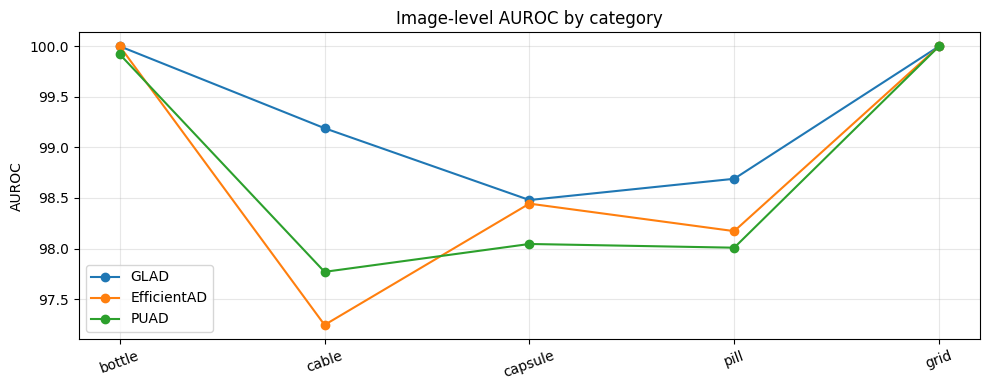

saved: /content/drive/MyDrive/industrial-anomaly-detection-app/comparison/figures/image_auroc_by_category.png


In [14]:
# かんたんな可視化（Image_AUROC）
import matplotlib.pyplot as plt

if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    for method in ["GLAD", "EfficientAD", "PUAD"]:
        sub = df[df["Method"] == method]
        ax.plot(sub["Category"], sub["Image_AUROC"], marker="o", label=method)
    ax.set_title("Image-level AUROC by category")
    ax.set_ylabel("AUROC")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.xticks(rotation=20)
    plt.tight_layout()
    fig_path = f"{FIG_ROOT}/image_auroc_by_category.png"
    plt.savefig(fig_path, dpi=180)
    plt.show()
    print("saved:", fig_path)


In [15]:
# Markdown 用の最終表
final_df = display_df.copy()
final_csv = f"{TABLE_ROOT}/multi_category_comparison_final.csv"
final_df.to_csv(final_csv, index=False)
print("saved:", final_csv)
final_df


saved: /content/drive/MyDrive/industrial-anomaly-detection-app/comparison/tables/multi_category_comparison_final.csv


,Method,Dataset,Category,Image_AUROC,Pixel_AUROC,Pixel_AP,PRO_or_AUPRO,Notes
0,GLAD,MVTec-AD,bottle,100.000,98.710,85.500,96.150,checkpoint_step=2500
1,EfficientAD,MVTec-AD,bottle,100.000,97.162,55.720,88.990,efficient_ad_pixel_eval
2,PUAD,MVTec-AD,bottle,99.921,NaN,NaN,NaN,feature_extractor=student
3,GLAD,MVTec-AD,cable,99.190,98.120,68.610,94.010,checkpoint_step=1500
4,EfficientAD,MVTec-AD,cable,97.245,98.231,66.039,90.743,efficient_ad_pixel_eval
5,PUAD,MVTec-AD,cable,97.770,NaN,NaN,NaN,feature_extractor=student
6,GLAD,MVTec-AD,capsule,98.480,98.540,53.670,94.240,checkpoint_step=2000
7,EfficientAD,MVTec-AD,capsule,98.444,98.605,33.174,91.914,efficient_ad_pixel_eval
8,PUAD,MVTec-AD,capsule,98.045,NaN,NaN,NaN,feature_extractor=student
9,GLAD,MVTec-AD,pill,98.690,97.900,75.990,97.600,checkpoint_step=1500
